# Laboratório 02
## Disciplina Aprendizado de Máquina 2
## Professor: Kaique Almeida




## Classificação com SVM e MLP

Dataset: https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data   

Beijing Multi-Site Air Quality

### Bibliotecas utilizadas

In [ ]:
pip install minisom

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text
import seaborn as sns
from sklearn.metrics import confusion_matrix

from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from minisom import MiniSom




### Exploração Inicial

In [ ]:
df = pd.read_csv('/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv')

In [ ]:
print(df.shape)
print(df.columns)

In [ ]:
df.head()

In [ ]:
df['Qualidade_Ar'] = pd.cut(
    df['PM2.5'],
    bins=[0, 35, 75, float('inf')],
    labels=['Boa', 'Moderada', 'Ruim'],
    include_lowest=True
).dropna()

In [ ]:
df.head()

In [ ]:
print(df['Qualidade_Ar'].value_counts())

In [ ]:

df_model = df[['TEMP', 'PRES', 'DEWP', 'RAIN', 'wd',
               'WSPM', 'SO2', 'NO2', 'CO', 'O3', 'Qualidade_Ar']].dropna()

x = df_model[['TEMP', 'PRES', 'DEWP', 'RAIN', 'wd',
              'WSPM', 'SO2', 'NO2', 'CO', 'O3']]
x = pd.get_dummies(x, columns=['wd'], drop_first=True)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

y = df_model['Qualidade_Ar']

In [ ]:
x.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### SVM

In [ ]:
%%time

#Tunning de parametros, não precisa rodar esta célula

param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 10],
    'gamma': ['scale', 0.1, 1]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=2,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

#### OvO

In [13]:
# OvO default
%%time
svm = SVC(
    kernel='rbf',
    C=1,
    random_state=42,
    gamma='scale'
)

svm.fit(X_train, y_train)

CPU times: user 23.9 s, sys: 358 ms, total: 24.3 s
Wall time: 24.5 s


SVC(C=1, random_state=42)

In [14]:
y_pred = svm.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         Boa       0.84      0.87      0.85      2288
    Moderada       0.58      0.53      0.55      1507
        Ruim       0.84      0.85      0.85      2570

    accuracy                           0.78      6365
   macro avg       0.75      0.75      0.75      6365
weighted avg       0.78      0.78      0.78      6365



In [ ]:
# Refaça o treinamento considerando C=0.01


Responda: O que mudou nos resultados com a diminuição do C? Qual a hipotése para essa diferença?

Sua resposta:   


Responda: Sabendo que o SVM por default implementa um classificador OvO para problemas multiclasse. Quais classificadores são criados no treinamento acima (liste os pares, exemplo: (A,B), (A,C))?  

Sua resposta:

#### OvR

In [15]:
%%time
svm_ovr = OneVsRestClassifier(
    SVC(
    kernel='rbf',
    C=1,
    random_state=42,
    gamma='scale'
)
)

svm_ovr.fit(X_train, y_train)

CPU times: user 52.3 s, sys: 277 ms, total: 52.6 s
Wall time: 53 s


OneVsRestClassifier(estimator=SVC(C=1, random_state=42))

In [16]:
y_pred = svm_ovr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         Boa       0.75      0.94      0.84      2288
    Moderada       0.69      0.08      0.15      1507
        Ruim       0.74      0.95      0.83      2570

    accuracy                           0.74      6365
   macro avg       0.72      0.66      0.60      6365
weighted avg       0.73      0.74      0.67      6365



Responda: Quais classificadores são criados no treinamento acima (liste os pares, exemplo: (A,B), (A,C))?? Compare os tempos de treinamento, e explique a diferença entre eles.

Sua resposta:

### MLP

In [17]:
%%time
mlp = MLPClassifier(
    hidden_layer_sizes=(25, 10),
    activation='relu',
    solver='adam',
    alpha=0.0001,                 # regularização L2
    batch_size='auto',
    learning_rate='adaptive',
    max_iter=1000,
    random_state=42
)


mlp.fit(X_train, y_train)

# Predições
y_pred = mlp.predict(X_test)

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


Relatório de Classificação:
              precision    recall  f1-score   support

         Boa       0.85      0.87      0.86      2288
    Moderada       0.60      0.52      0.56      1507
        Ruim       0.83      0.88      0.86      2570

    accuracy                           0.79      6365
   macro avg       0.76      0.76      0.76      6365
weighted avg       0.79      0.79      0.79      6365

CPU times: user 19.8 s, sys: 16.3 ms, total: 19.9 s
Wall time: 19.9 s


In [18]:
print("=== MLP SUMMARY ===")
print(f"Entradas: {mlp.n_features_in_}")
print(f"Camadas ocultas: {mlp.hidden_layer_sizes}")
print(f"Número de camadas: {mlp.n_layers_}")
print(f"Função de ativação: {mlp.activation}")
print(f"Ativação de saída: {mlp.out_activation_}")
print(f"Classes: {mlp.classes_}")

=== MLP SUMMARY ===
Entradas: 24
Camadas ocultas: (25, 10)
Número de camadas: 4
Função de ativação: relu
Ativação de saída: softmax
Classes: ['Boa' 'Moderada' 'Ruim']


Responda: Explique cada um dos hiper parâmetros utilizados no instanciamento da MLP.



Sua resposta:

Responda: Por que é utilizada a função de ativação softmax na saída? Como ela funciona?

Sua resposta:

In [19]:
# Nesta célula treine novamente a mlp trocando alguns hiperparâmetros.

Descreva sua experiência com os testes.

### Agrupamento com Redes de Kohonen

In [20]:
def plot_som_classes(
    x_scaled,
    y_classes,
    som_x=10,
    som_y=10,
    sigma=1.5,
    learning_rate=0.5,
    num_iteration=5000,
    sample_size=5000,
    random_seed=42,
    alpha=0.5,
    point_size=20
):

    som = MiniSom(
        x=som_x,
        y=som_y,
        input_len=x_scaled.shape[1],
        sigma=sigma,
        learning_rate=learning_rate,
        random_seed=random_seed
    )

    som.random_weights_init(x_scaled)

    som.train_random(
        x_scaled,
        num_iteration=num_iteration
    )

    n_samples = min(sample_size, len(x_scaled))

    idx = np.random.choice(
        len(x_scaled),
        size=n_samples,
        replace=False
    )

    cores = {
        'Boa': 'green',
        'Moderada': 'orange',
        'Ruim': 'red'
    }

    # Ajusta automaticamente o tamanho da figura
    #fig_size = max(som_x, som_y)

    plt.figure(figsize=(10, 10))

    for i in idx:

        winner = som.winner(x_scaled[i])

        plt.scatter(
            winner[0] + np.random.uniform(-0.3, 0.3),
            winner[1] + np.random.uniform(-0.3, 0.3),
            c=cores[y_classes.iloc[i]],
            alpha=alpha,
            s=point_size
        )


    plt.xticks(np.arange(som_x))
    plt.yticks(np.arange(som_y))

    plt.xlim(-0.5, som_x - 0.5)
    plt.ylim(-0.5, som_y - 0.5)

    plt.grid(True)

    plt.title(
        f"SOM {som_x}x{som_y} | σ={sigma} | lr={learning_rate}"
    )

    plt.tight_layout()
    plt.show()

    return som

/usr/local/lib/python3.12/dist-packages/minisom.py:165: UserWarning: Warning: sigma might be too high for the dimension of the map.
  warn('Warning: sigma might be too high ' +


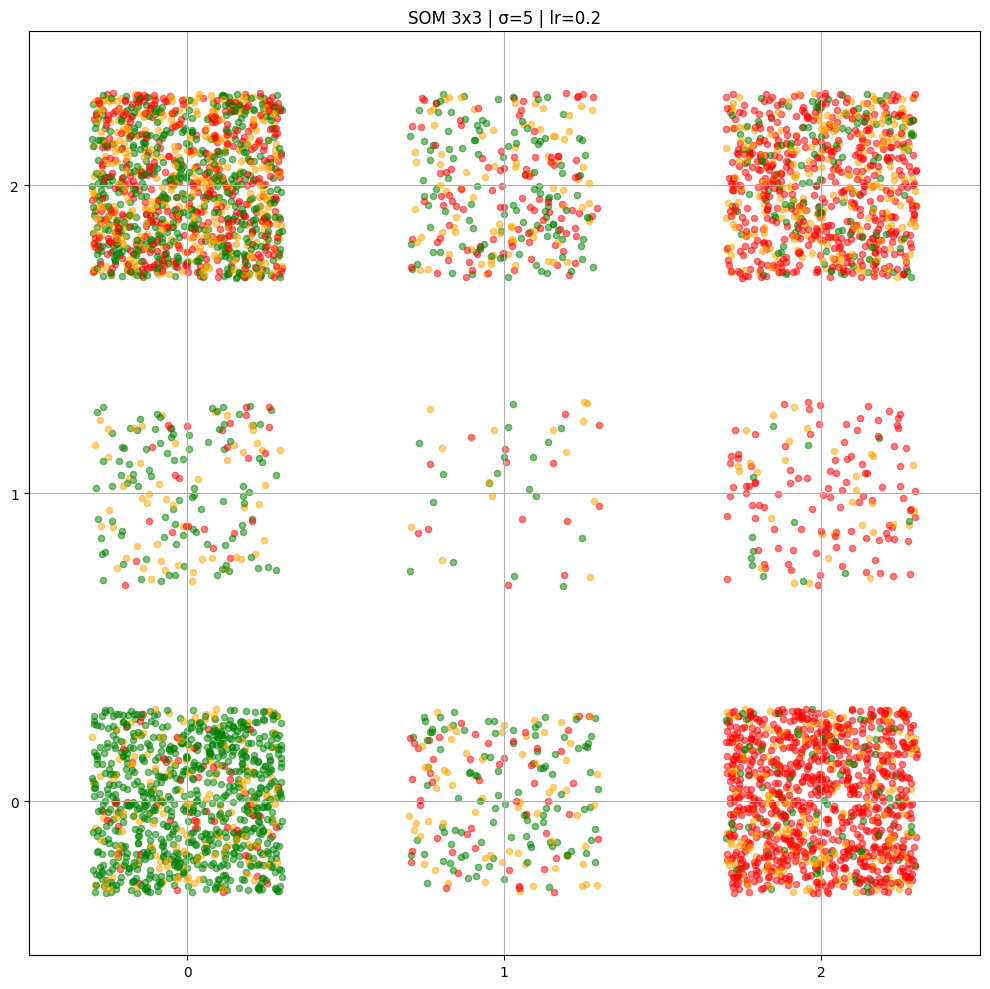

CPU times: user 1min 20s, sys: 146 ms, total: 1min 20s
Wall time: 1min 21s


In [21]:
%%time
som = plot_som_classes(
    x_scaled=x_scaled,
    y_classes=y,
    som_x=3,
    som_y=3,
    sigma=5,
    learning_rate=0.2,
    num_iteration=10000,
    sample_size=5000
)

Responda: O que representa cada vértice no gráfico acima?

Sua resposta:

Responda: Qual a relação entre o mapa e os resultados dos classificadores?


Sua resposta:


In [ ]:
# Rode a função novamente trocando os hiperparâmetros

Descreva sua experiência com os testes

Sua resposta: